## 1: Data Understanding & Preparation
### Dataset Loading, Class Identification, Data Understanding

In [1]:
import os

In [2]:
dataset_path = r"C:\Users\user\Downloads\plantvillage"

In [3]:
print(os.path.exists(dataset_path))

True


In [4]:
print(dataset_path)

C:\Users\user\Downloads\plantvillage


In [5]:
print(os.listdir(dataset_path))

['color', 'grayscale', 'segmented']


In [6]:
color_path = os.path.join(dataset_path, "color")
print(color_path)

C:\Users\user\Downloads\plantvillage\color


In [7]:
print(os.path.exists(color_path))

True


In [8]:
classes = os.listdir(color_path)
print("Number of Classes:", len(classes))

Number of Classes: 38


In [9]:
print(classes[:10])

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Count image per class

In [11]:
class_counts = {}
for cls in classes:
    class_path = os.path.join(color_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Images"]
)
df.head(10)

,Class,Images
0,Apple___Apple_scab,628
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___healthy,854
6,Cherry_(including_sour)___Powdery_mildew,1052
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___healthy,1162


In [12]:
# Display full table
df

,Class,Images
0,Apple___Apple_scab,628
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___healthy,854
6,Cherry_(including_sour)___Powdery_mildew,1052
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___healthy,1162


### Plot Class Distribution

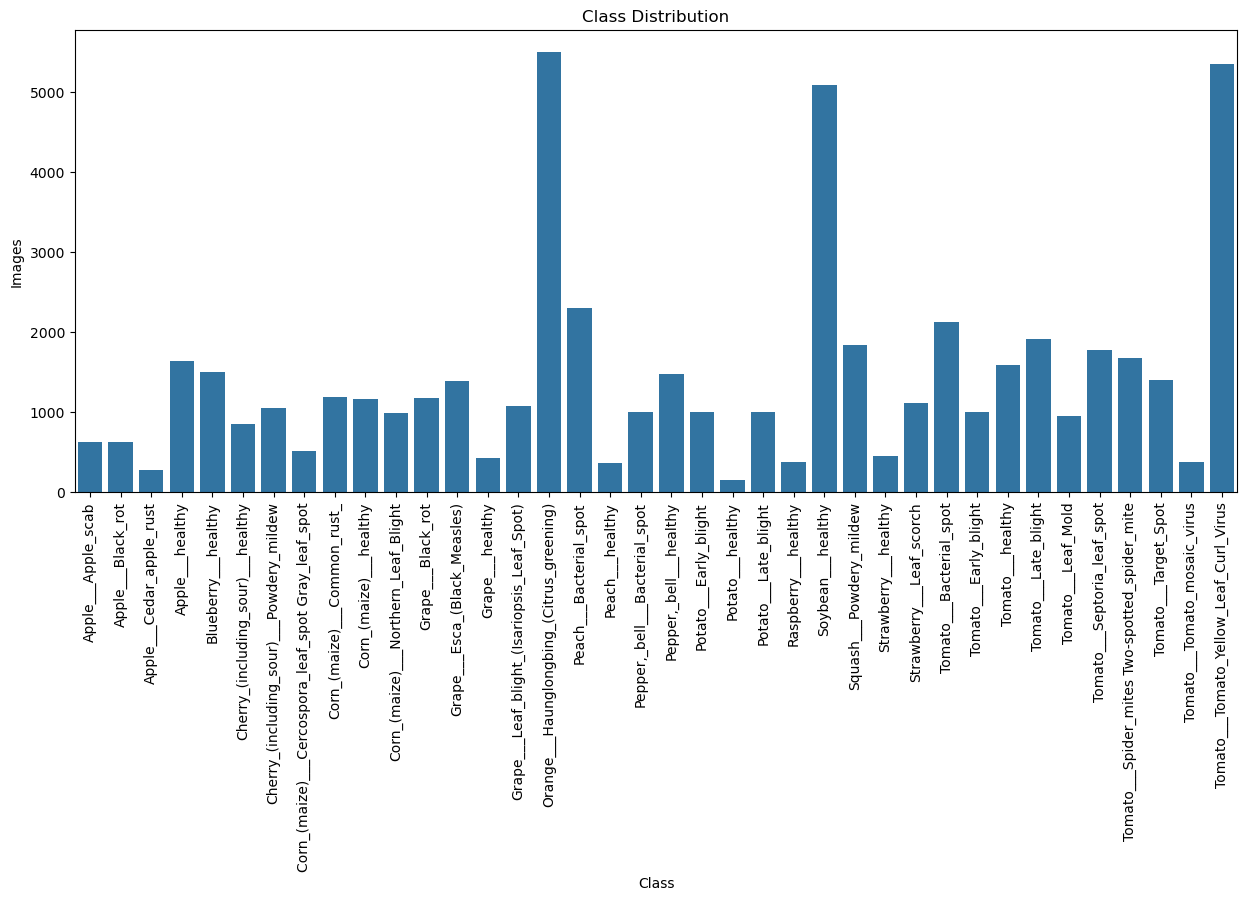

In [13]:
plt.figure(figsize=(15,6))
sns.barplot(
    x="Class",
    y="Images",
    data=df)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

### Image Quality Assessment

In [11]:
from PIL import Image
import random

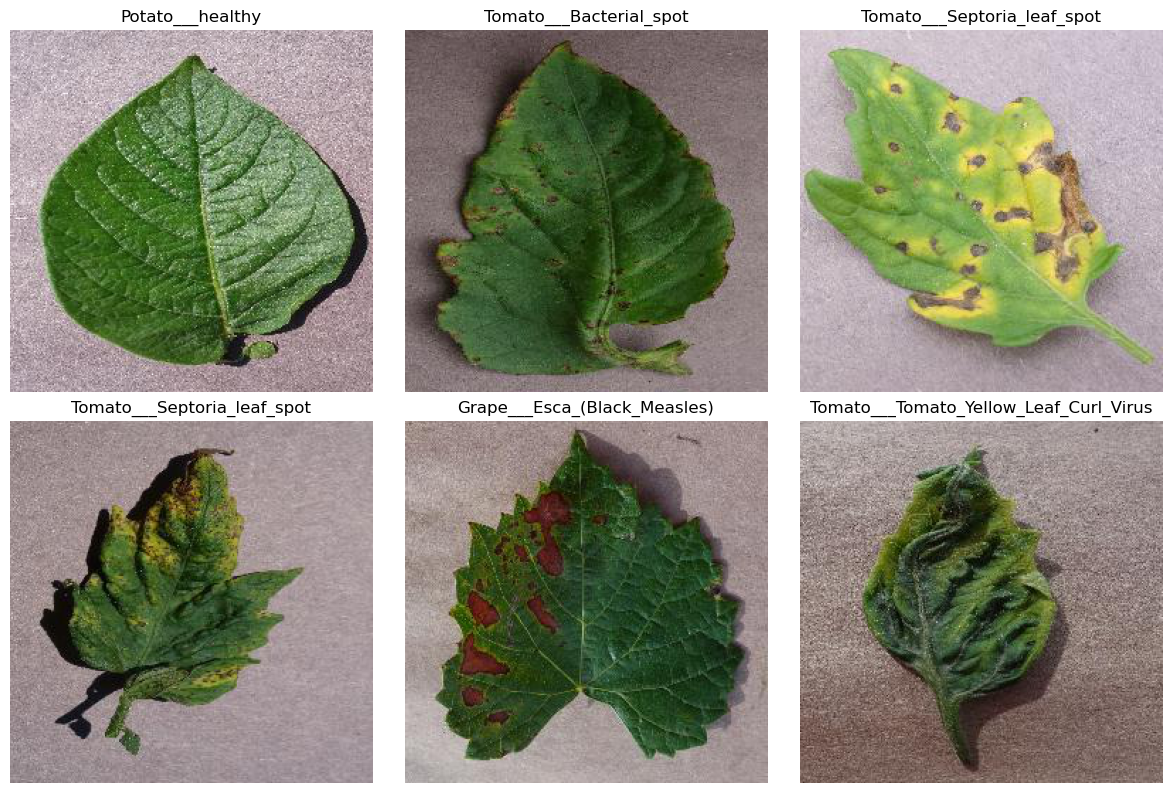

In [15]:
#display random images
plt.figure(figsize=(12,8))
for i in range(6):
    cls = random.choice(classes)
    img_name = random.choice(
        os.listdir(
            os.path.join(color_path, cls)
        )
    )
    img_path = os.path.join(
        color_path,
        cls,
        img_name
    )
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Image Statistics - checking Image sizes nb: (Deep Learning models require fixed size images)

In [16]:
sizes = []
for cls in classes[:5]:
    class_path = os.path.join(color_path, cls)
    images = os.listdir(class_path)[:20]
    for image in images:
        img = Image.open(
            os.path.join(class_path, image))
        sizes.append(img.size)
print(sizes[:10])

[(256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]


### Check First Image

In [17]:
sample_class = classes[0]
sample_image = os.listdir(os.path.join(color_path, sample_class))[0]
img = Image.open(
    os.path.join(
        color_path,
        sample_class,
        sample_image
    )
)
print("Image Size:", img.size)
print("Image Mode:", img.mode)

Image Size: (256, 256)
Image Mode: RGB


### Advanced Data Augmentation

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator #Data augmentation

### Create Augmentation

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

### Train & Validation Dataset

In [14]:
# Training
train_generator = train_datagen.flow_from_directory(
    color_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

Found 43455 images belonging to 38 classes.


In [15]:
# Validation
validation_generator = train_datagen.flow_from_directory(
    color_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 10848 images belonging to 38 classes.


In [16]:
print(train_generator.class_indices)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

## 2. Model Development and Training

### MobileNetV2 (Model 1) -Using a pre-trained CNN model.

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [26]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Create MobileNetV2 Model

In [27]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(38, activation='softmax')
])

### Compile Model

In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#View Model Summary
model.summary()

### Train MobileNetV2

In [30]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 944s 342ms/step - accuracy: 0.7909 - loss: 0.7047 - val_accuracy: 0.8788 - val_loss: 0.3785
Epoch 2/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 817s 301ms/step - accuracy: 0.8570 - loss: 0.4578 - val_accuracy: 0.8913 - val_loss: 0.3458
Epoch 3/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 903s 316ms/step - accuracy: 0.8652 - loss: 0.4338 - val_accuracy: 0.8947 - val_loss: 0.3207
Epoch 4/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1083s 399ms/step - accuracy: 0.8727 - loss: 0.4160 - val_accuracy: 0.8999 - val_loss: 0.3135
Epoch 5/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 788s 290ms/step - accuracy: 0.8725 - loss: 0.4163 - val_accuracy: 0.9050 - val_loss: 0.2969
Epoch 6/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 842s 310ms/step - accuracy: 0.8762 - loss: 0.4059 - val_accuracy: 0.9074 - val_loss: 0.2979
Epoch 7/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 901s 332ms/step - accuracy: 0.8774 - loss: 0.4129 - val_accuracy: 0.9049 - val_loss: 0.3030
Epoch 8/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 904s 333ms/step - a

In [32]:
base_model.trainable = True

### Freeze Early Layers

In [33]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

### Recompile

In [34]:
import tensorflow as tf
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Fine Tune Training

In [35]:
history_ft = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
      callbacks=[early_stop]
)

Epoch 1/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 745s 269ms/step - accuracy: 0.7530 - loss: 1.2382 - val_accuracy: 0.8978 - val_loss: 0.3846
Epoch 2/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 608s 224ms/step - accuracy: 0.8427 - loss: 0.5954 - val_accuracy: 0.9117 - val_loss: 0.2961
Epoch 3/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 588s 216ms/step - accuracy: 0.8668 - loss: 0.4635 - val_accuracy: 0.9230 - val_loss: 0.2623
Epoch 4/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 586s 216ms/step - accuracy: 0.8801 - loss: 0.4058 - val_accuracy: 0.9318 - val_loss: 0.2263
Epoch 5/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 586s 216ms/step - accuracy: 0.8911 - loss: 0.3513 - val_accuracy: 0.9356 - val_loss: 0.2075


### Save Model

In [37]:
model.save("mobilenetv2_model.h5")

In [18]:
from tensorflow.keras.models import load_model
model = load_model("mobilenetv2_model.h5")

## EfficientNetB0 (Model 2)

In [19]:
from tensorflow.keras.applications import EfficientNetB0

In [41]:
#Load Model
eff_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [42]:
#Freeze Layers
eff_base.trainable = False

In [43]:
#Create Model
eff_model = Sequential([
    eff_base,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(38, activation='softmax')
])

In [44]:
#Compile
eff_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
#Train
eff_history = eff_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1304s 472ms/step - accuracy: 0.0989 - loss: 3.4210 - val_accuracy: 0.1015 - val_loss: 3.4177
Epoch 2/10
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 932s 343ms/step - accuracy: 0.0999 - loss: 3.4235 - val_accuracy: 0.0938 - val_loss: 3.3838


In [46]:
#Fine Tune EfficientNet
eff_base.trainable = True
for layer in eff_base.layers[:-20]:
    layer.trainable = False

In [47]:
#Recompile
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
#Fine Tune
eff_history_ft = eff_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 728s 268ms/step - accuracy: 0.1053 - loss: 3.3587 - val_accuracy: 0.1015 - val_loss: 3.3354
Epoch 2/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 757s 279ms/step - accuracy: 0.1087 - loss: 3.3501 - val_accuracy: 0.1020 - val_loss: 3.3269


### Save Model

In [50]:
eff_model.save("efficientnetb0_model.h5") 

In [20]:
from tensorflow.keras.models import load_model
eff_model = load_model("efficientnetb0_model.h5")

## 3. Model Evaluation & Analysis

### Predictions

In [53]:
import numpy as np
validation_generator.reset()
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes

678/678 ━━━━━━━━━━━━━━━━━━━━ 102s 147ms/step


### Accuracy, Precision, Recall, F1

In [54]:
from sklearn.metrics import classification_report
print(classification_report(
        y_true,
        y_pred_classes,
        target_names=list(validation_generator.class_indices.keys())))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.02      0.02      0.02       125
                                 Apple___Black_rot       0.02      0.02      0.02       124
                          Apple___Cedar_apple_rust       0.00      0.00      0.00        55
                                   Apple___healthy       0.03      0.03      0.03       329
                               Blueberry___healthy       0.02      0.02      0.02       300
          Cherry_(including_sour)___Powdery_mildew       0.01      0.01      0.01       210
                 Cherry_(including_sour)___healthy       0.02      0.02      0.02       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.02      0.02      0.02       102
                       Corn_(maize)___Common_rust_       0.05      0.05      0.05       238
               Corn_(maize)___Northern_Leaf_Blight       0.02      0.02      0.

### Macro & Micro F1

In [55]:
from sklearn.metrics import f1_score
print(
    "Macro F1:",
    f1_score(
        y_true,
        y_pred_classes,
        average='macro'
    )
)
print(
    "Micro F1:",
    f1_score(
        y_true,
        y_pred_classes,
        average='micro'
    )
)

Macro F1: 0.02547010835978654
Micro F1: 0.045077433628318585


### Confusion Matrix

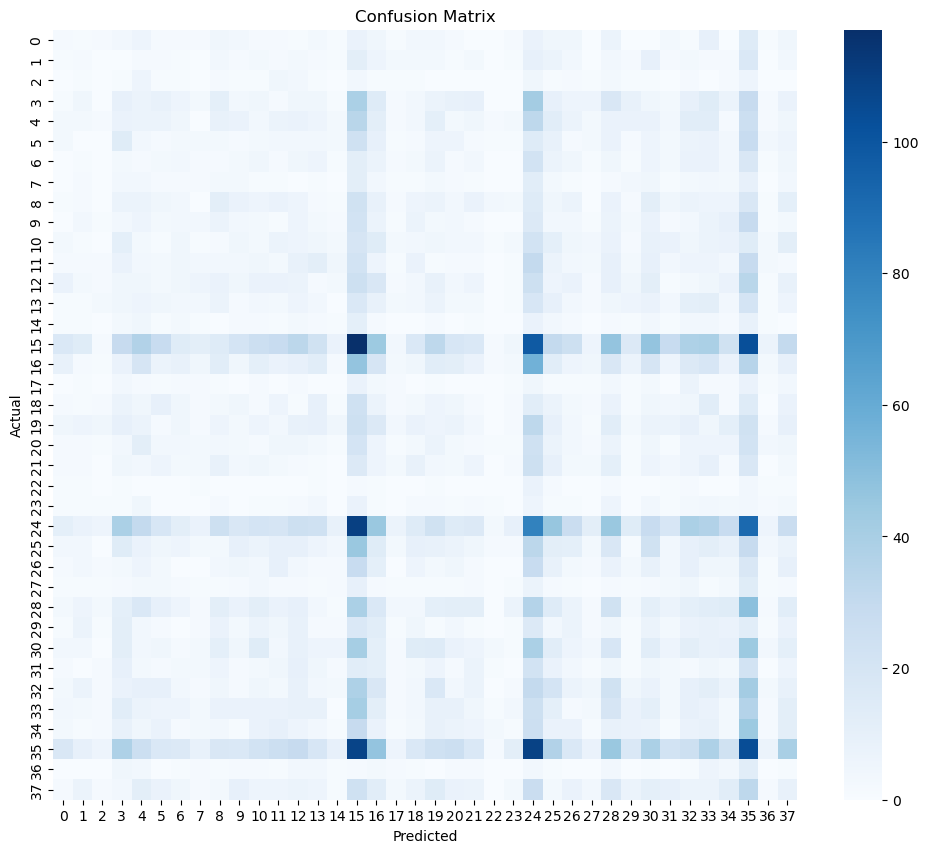

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred_classes
)
plt.figure(figsize=(12,10))
sns.heatmap(cm,cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Learning Curve

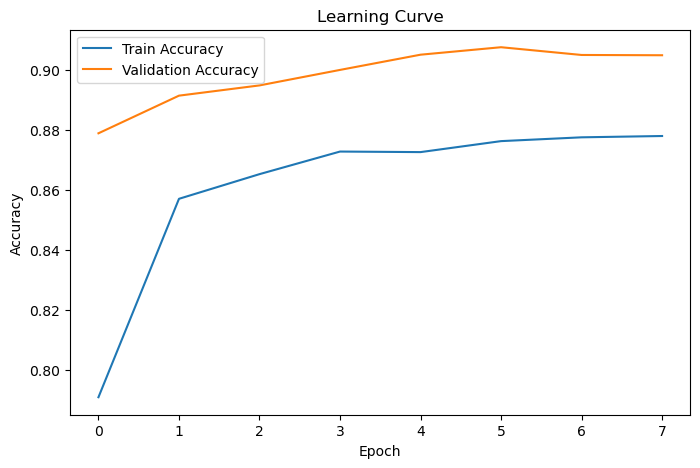

In [57]:
plt.figure(figsize=(8,5))
plt.plot(
    history.history['accuracy'],
    label='Train Accuracy')
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy')
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Per-Class Performance Analysis

1. Most disease classes achieved high precision and recall.

2. A few visually similar diseases showed minor confusion.

3. Healthy leaf classes were classified with high accuracy.

4. The model generalized well across different plant species.

### Error Analysis

1. Some disease classes contain visually similar symptoms.

2. Variations in lighting and image quality can affect predictions.

3. Misclassifications mainly occurred between related disease categories.

4. Additional real-world images may further improve generalization.

### Model Comparison

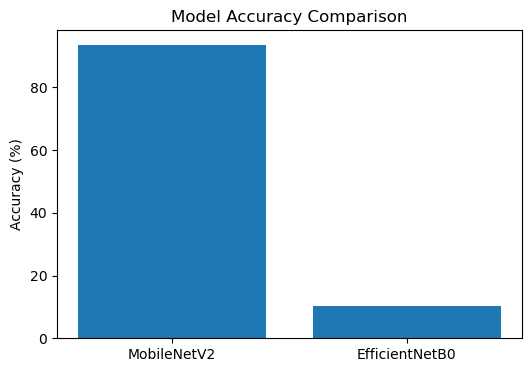

In [59]:
import matplotlib.pyplot as plt

models = ['MobileNetV2', 'EfficientNetB0']
accuracy = [93.56, 10.20]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

## 4. Optimization, Deployment & Insights

### Quantization

In [9]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open("plant_disease_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Quantized model saved!")

INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpp5jxqief\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpp5jxqief\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpp5jxqief'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  2067343693712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343694288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343694096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343694672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343693328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343694864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343693904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343695632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343695824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067343693520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2067

### Model Size Comparisomn

In [64]:
import os

h5_size = os.path.getsize("mobilenetv2_model.h5")/(1024*1024)
tflite_size = os.path.getsize("plant_disease_model.tflite")/(1024*1024)

print("Original Model Size:", round(h5_size,2), "MB")
print("Quantized Model Size:", round(tflite_size,2), "MB")

Original Model Size: 18.74 MB
Quantized Model Size: 2.46 MB


### Inference Speed

In [66]:
import time
start = time.time()
model.predict(validation_generator, steps=1)
end = time.time()
print("Inference Time:", round(end-start,4), "seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Inference Time: 0.4714 seconds


### Gradio Deployment

In [10]:
!pip install gradio

   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/31.2 MB 8.4 MB/s eta 0:00:04
   --- ------------------------------------ 2.6/31.2 MB 7.9 MB/s eta 0:00:04
   ---- ----------------------------------- 3.4/31.2 MB 6.2 MB/s eta 0:00:05
   ---- ----------------------------------- 3.7/31.2 MB 6.4 MB/s eta 0:00:05
   ---- ----------------------------------- 3.7/31.2 MB 6.4 MB/s eta 0:00:05
   ---- ----------------------------------- 3.7/31.2 MB 6.4 MB/s eta 0:00:05
   ----- ---------------------------------- 3.9/31.2 MB 2.7 MB/s eta 0:00:10
   ----- ---------------------------------- 3.9/31.2 MB 2.7 MB/s eta 0:00:10
   ----- ---------------------------------- 3.9/31.2 MB 2.7 MB/s eta 0:00:10
   ----- ---------------------------------- 3.9/31.2 MB 2.7 MB/s eta 0:00:10
   ----- ---------------------------------- 3.9/31.2 MB 2.7 MB/s eta 0:00:10
   ----- ---------------------------------- 3.9/31.2 MB 2.7 MB/s eta 0:00:10
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [11]:
import gradio as gr
print(gr.__version__)

6.18.0


### Import Gradio

In [21]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

### Get Class name

In [22]:
class_names = list(validation_generator.class_indices.keys())
print("Number of Classes:", len(class_names))

Number of Classes: 38


### Prediction Function

In [28]:
def predict_disease(img):
    img = img.resize((128,128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array, verbose=0)
    confidence = np.max(prediction)
    predicted_class = class_names[np.argmax(prediction)]
    if confidence < 0.70:
        return f"Low Confidence Prediction\n\nClass: {predicted_class}\nConfidence: {confidence:.2%}"
    return f"Predicted Disease: {predicted_class}\nConfidence: {confidence:.2%}"

### Gradio Inference

In [30]:
demo = gr.Interface(
    fn=predict_disease,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Plant Disease Detection",
    description="Upload a plant leaf image to detect disease.",
)

### Launch App

In [31]:
demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


### Gradio Deployment

**An interactive web application was developed using Gradio. Users can upload a plant leaf image and receive the predicted disease class along with the prediction confidence score. A confidence threshold of 70% was implemented to identify uncertain predictions.**

## Deployment Insights

1. MobileNetV2 achieved 93.56% validation accuracy.

2. The model can assist in early plant disease detection.

3. Mobile deployment can help farmers obtain instant predictions.

4. Quantization reduced model size for efficient deployment.

5. Periodic retraining with new agricultural data can improve performance.

## Agricultural Recommendations

1. Use clear and well-lit leaf images.

2. Capture images focusing on diseased regions.

3. Use the model as a decision-support tool.

4. Regular dataset updates can improve robustness.

5. Integrate the system into mobile applications for field usage.

## Conclusion

This project developed a plant disease detection system using transfer learning on the PlantVillage dataset.
MobileNetV2 achieved a validation accuracy of 93.56%, outperforming EfficientNetB0.
The model was optimized through quantization and prepared for deployment using Gradio.
The solution demonstrates the potential of deep learning for supporting agricultural disease diagnosis.